In [1]:
# General stuff
import logging
import sys

# Astropy stuff
import astropy.units as u
import pytest 

# zHunter stuff
from zhunter.conversions import *


log = logging.getLogger(__name__)
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG,
                    format="%(asctime)s.%(msecs)03d | %(levelname)-8s | %(funcName)s - %(filename)s:%(lineno)d : %(message)s",

                    )
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

In [2]:
# Try with quantity and float
fwhms = [2.0 * u.arcsec, 0.1*u.arcmin, 1*u.nm, 2.0]
for fwhm in fwhms:
    print(fwhm_to_sigma(fwhm=fwhm))

0.8493218002880191 arcsec
0.04246609001440096 arcmin
0.42466090014400953 nm
0.8493218002880191


In [3]:
# Try with quantity and float
sigmas = [2.0 * u.arcsec, 0.1*u.arcmin, 1*u.nm, 2.0]
for sigma in sigmas:
    print(sigma_to_fwhm(sigma=sigma))

4.709640090061899 arcsec
0.23548200450309495 arcmin
2.3548200450309493 nm
4.709640090061899


In [4]:
vels = [100*u.Unit("km/s"), 10*u.Unit("m/s"), 10*u.Unit("km/h"), 10*u.Unit("m/h")]
for vel in vels:
    print(fwhm_v2w(fwhm_v=vel, w0=656.3*u.nm))

# Try with invalid inputs
with pytest.raises(TypeError):
    fwhm_v2w(fwhm_v=10, w0=656.3)

# Invalid unit
with pytest.raises(u.UnitsError):
    fwhm_v2w(fwhm_v=10*u.m, w0=656.3*u.nm)


0.21891811567820696 nm
2.1891811456953292e-05 nm
6.081058472773293e-06 nm
6.080654202378355e-09 nm


In [5]:
wvlgs = [1e-9*u.Unit("m"), 1*u.Unit("nm"), 0.001*u.Unit("um"), 10*u.Unit("AA")]
for wvlg in wvlgs:
    print(fwhm_w2v(fwhm_w=wvlg, w0=656.3*u.nm))

# Try with invalid inputs
with pytest.raises(TypeError):
    fwhm_w2v(fwhm_w=10, w0=656.3)

456.7917994820032 km / s
456.7917994820032 km / s
456.7917994820032 km / s
456.7917994820032 km / s


In [6]:
convert_flux_with_unc_propagation(
    flux=1*u.uJy,
    unc=0.1*u.uJy,
    to_unit=u.ABmag,
)

convert_flux_with_unc_propagation(
        flux=1*u.uJy,
        unc=0.1*u.uJy,
        to_unit=ergscm2AA,
        central_wavelength=656.3*u.nm,
    )

convert_flux_with_unc_propagation(
        flux=1*ergscm2AA,
        unc=0.1*ergscm2AA,
        to_unit=u.ABmag,
        central_wavelength=656.3*u.nm,
    )


# Try with unit-less inputs
with pytest.raises(TypeError):
    convert_flux_with_unc_propagation(
        flux=1,
        unc=0.1,
        to_unit=u.uJy,
    )

# Try with invalid unit input
with pytest.raises(u.UnitsError):
    convert_flux_with_unc_propagation(
        flux=1*u.m,
        unc=0.1*u.m,
        to_unit=u.m,
    )



2024-11-05 11:42:08,224.224 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:86 : Converting flux from uJy to mag(AB).
2024-11-05 11:42:08,229.229 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:115 : Using Monte Carlo sampling for error propagation.
2024-11-05 11:42:08,235.235 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:86 : Converting flux from uJy to erg/s/cm2/AA.
2024-11-05 11:42:08,239.239 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:115 : Using Monte Carlo sampling for error propagation.
2024-11-05 11:42:08,242.242 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:86 : Converting flux from erg/s/cm2/AA to mag(AB).
2024-11-05 11:42:08,244.244 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:115 : Using Monte Carlo sampling for error propagation.


2024-11-05 11:44:03,981.981 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:86 : Converting flux from erg / (Angstrom s cm2) to 1e-11 erg / (Hz s cm2).
2024-11-05 11:44:03,983.983 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:115 : Using Monte Carlo sampling for error propagation.


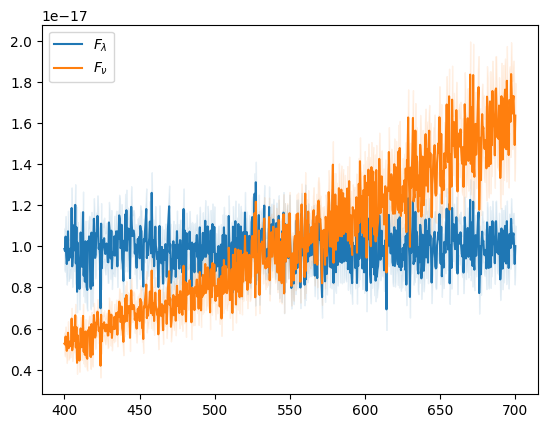

In [15]:
import matplotlib.pyplot as plt
from zhunter.misc import generate_fake_1D_spectrum

wvlg, flux, unc = generate_fake_1D_spectrum(spec_start=400, spec_end=700, N_spec=750)

f_Jy, unc_p, unc_m = convert_flux_with_unc_propagation(
        flux=flux,
        unc=unc,
        to_unit=1e-11*u.Unit("erg s-1 cm-2 Hz-1"),
        central_wavelength=wvlg,
    )
fig, ax = plt.subplots()
ax.plot(wvlg, flux, label=r"$F_{\lambda}$", color="C0")
ax.fill_between(wvlg.value, (flux+unc).value, (flux-unc).value, color="C0", alpha=0.1)
ax.plot(wvlg, f_Jy, label=r"$F_{\nu}$", color="C1")
ax.fill_between(wvlg.value, (f_Jy+unc_p).value, (f_Jy-unc_m).value, color="C1", alpha=0.1)
ax.legend()